### Imports and paths

In [1]:
import sys
from pathlib import Path
from typing import Dict, Any, Tuple

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import time

from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

ROOT = Path.cwd().resolve().parent  # es. se notebook è in /notebooks

if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths

paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

MODEL_SPECS = {
    "teacher_base":{
        "display_name": "Teacher Base",
        "ckpt_path": "google-bert/bert-base-uncased",
        "threshold": 0.42,
        "bar_color": "#b96329",   
        "cm_cmap": "Oranges",    
        "n_params": 109_482_240, 
    },
    "teacher_ft": {
        "display_name": "Teacher Fine-Tuned",
        "ckpt_path": CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000",   
        "threshold": 0.52,
        "bar_color": "#c0392b",   
        "cm_cmap": "Blues",   
        "n_params": 109_482_240,    
    },
    "student_base":{
        "display_name": "Student Base",
        "ckpt_path": "huawei-noah/TinyBERT_General_4L_312D",  
        "threshold": 0.01,
        "bar_color": "#27ae60",   
        "cm_cmap": "Greens",    
        "n_params": 14_500_000,   
    },
    "student_kd": {
        "display_name": "Student Distilled",
        "ckpt_path": CKPT_DIR / "tinybert_phase2" / "checkpoint-13000",  
        "threshold": 0.50,
        "bar_color": "#1f4e79",   
        "cm_cmap": "Reds",  
        "n_params": 14_500_000,   
    },
}



for k, v in MODEL_SPECS.items():
    print(f"{k}:")
    print("  path      =", v["ckpt_path"])
    print("  threshold =", v["threshold"])

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints
teacher_base:
  path      = google-bert/bert-base-uncased
  threshold = 0.42
teacher_ft:
  path      = C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
  threshold = 0.52
student_base:
  path      = huawei-noah/TinyBERT_General_4L_312D
  threshold = 0.01
student_kd:
  path      = C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000
  threshold = 0.5


### Loading test set

In [2]:
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

required_cols = {"input_ids", "attention_mask", "labels"}
missing_cols = required_cols - set(test_ds.column_names)
if missing_cols:
    raise ValueError(f"Mancano colonne nel test set: {missing_cols}")

print("Test size:", len(test_ds))
print("Columns:", test_ds.column_names)
print("Sample keys:", test_ds[0].keys())

Test size: 31344
Columns: ['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids']
Sample keys: dict_keys(['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids'])


In [3]:
@torch.no_grad() 
def measure_inference_time(trainer: Trainer, ds, warmup_batches: int = 5) -> Dict[str, float]:
    model = trainer.model
    model.eval() 
    dataloader = trainer.get_eval_dataloader(ds)

    for i, batch in enumerate(dataloader):
        if i >= warmup_batches:
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = model(**batch)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    n_samples = 0
    for batch in dataloader:
        bs = batch["input_ids"].shape[0]
        n_samples += bs
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = model(**batch)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()
    total_s = end - start

    return {
        "total_seconds": float(total_s),
        "ms_per_sample": float((total_s / n_samples) * 1000.0),
        "samples_per_second": float(n_samples / total_s),
        "n_samples": int(n_samples),
    }

def make_infer_trainer(model_path: Path, per_device_eval_batch_size: int = 32) -> Trainer:
    """
    Crea un Trainer per sola inferenza da un checkpoint HF.
    """
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path)).to(device)
    model.eval()

    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir=str(CKPT_DIR / "_tmp_eval_graphs"),
        per_device_eval_batch_size=per_device_eval_batch_size,
        dataloader_num_workers=2,
        report_to="none",
        fp16=False,   
    )

    trainer = Trainer(
        model=model,
        args=args,
        data_collator=collator,
        tokenizer=tokenizer,
    )
    return trainer


def logits_to_positive_probs(predictions: np.ndarray) -> np.ndarray:
    """
    Converte predictions del Trainer in probabilità della classe positiva.
    Gestisce sia output [N,2] (softmax) sia [N] / [N,1] (sigmoid).
    """
    logits = torch.tensor(predictions)

    if logits.ndim == 2 and logits.shape[1] == 2:
        probs = torch.softmax(logits, dim=-1)[:, 1]
    elif logits.ndim == 1:
        probs = torch.sigmoid(logits)
    elif logits.ndim == 2 and logits.shape[1] == 1:
        probs = torch.sigmoid(logits[:, 0])
    else:
        raise ValueError(f"Shape logits non gestita: {tuple(logits.shape)}")

    return probs.cpu().numpy()


def predict_probs_and_labels(trainer: Trainer, ds) -> Tuple[np.ndarray, np.ndarray]:
    """
    Esegue predict() su ds e restituisce:
    - y_true (int)
    - probs classe positiva
    """
    pred_out = trainer.predict(ds)
    probs = logits_to_positive_probs(pred_out.predictions)
    y_true = pred_out.label_ids.astype(int)
    return y_true, probs


def compute_metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> Dict[str, float]:
    """
    Calcola metriche principali su probabilità + soglia.
    """
    y_pred = (probs >= threshold).astype(int)

    metrics = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, probs)),
        "PR-AUC": float(average_precision_score(y_true, probs)),
        "Pred Positive Rate": float(y_pred.mean()),
    }
    return metrics


def compute_confusion_matrix(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> np.ndarray:
    """
    Restituisce confusion matrix [[TN, FP], [FN, TP]].
    """
    y_pred = (probs >= threshold).astype(int)
    return confusion_matrix(y_true, y_pred, labels=[0, 1])


def row_normalize_cm(cm: np.ndarray) -> np.ndarray:
    """
    Normalizza per riga (utile con class imbalance).
    """
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums


def evaluate_model_on_test(spec: Dict[str, Any], test_ds, batch_size: int = 32, measure_time: bool = True) -> Dict[str, Any]:
    """
    Pipeline completa per un modello:
    - carica checkpoint
    - inferenza sul test set
    - metriche
    - confusion matrix
    """
    trainer = make_infer_trainer(spec["ckpt_path"], per_device_eval_batch_size=batch_size)
    y_true, probs = predict_probs_and_labels(trainer, test_ds)

    threshold = spec["threshold"]
    metrics = compute_metrics_from_probs(y_true, probs, threshold)
    cm = compute_confusion_matrix(y_true, probs, threshold)

    timing = None 
    if measure_time:
        timing = measure_inference_time(trainer, test_ds, warmup_batches=5)

    return {
        "display_name": spec["display_name"],
        "threshold": threshold,
        "y_true": y_true,
        "probs": probs,
        "metrics": metrics,
        "cm": cm,
        "n_params": spec.get("n_params", None),
        "timing": timing,
    }


def build_metrics_dataframe(results_dict: Dict[str, Dict[str, Any]], metrics_order=None) -> pd.DataFrame:
    """
    Converte risultati in DataFrame long-form per seaborn barplot.
    """
    if metrics_order is None:
        metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]

    rows = []
    for model_key, res in results_dict.items():
        for metric_name in metrics_order:
            rows.append({
                "ModelKey": model_key,
                "Model": res["display_name"],
                "Metric": metric_name,
                "Value": res["metrics"][metric_name],
            })

    df = pd.DataFrame(rows)
    df["Metric"] = pd.Categorical(df["Metric"], categories=metrics_order, ordered=True)
    return df

In [4]:
fontsize =11

def plot_confusion_matrices(
    results_dict: Dict[str, Dict[str, Any]],
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    label_names=("No Spoiler", "Spoiler"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=fontsize,
):
    """
    Plotta due confusion matrix affiancate (teacher/student) con seaborn.
    normalized=False -> conteggi assoluti
    normalized=True  -> percentuali per riga
    """
    sns.set_theme(style="white", context="notebook")

    # estrai cm
    cms = []
    for k in model_keys:
        cm = results_dict[k]["cm"]
        if normalized:
            cm = row_normalize_cm(cm)
        cms.append(cm)

    # stesso range colore per confronto corretto
    vmax = max(cm.max() for cm in cms)
    vmin = 0.0

    fig, axes = plt.subplots(1, len(model_keys), figsize=figsize)
    if len(model_keys) == 1:
        axes = [axes]

    for ax, k, cm in zip(axes, model_keys, cms):
        spec = specs_dict[k]
        res = results_dict[k]

        sns.heatmap(
            cm,
            annot=True,
            fmt=".2%" if normalized else "d",
            cmap=spec["cm_cmap"],
            cbar=False,
            square=True,            # celle quadrate
            linewidths=0.6,
            linecolor="white",
            vmin=vmin,
            vmax=vmax,
            xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={"size": annot_fontsize},
            ax=ax
        )

        title_suffix = "Normalized" if normalized else "Test set"
        ax.set_title(
            f"{res['display_name']}",
            fontsize=12
        )
        ax.set_xlabel("Predicted label", fontsize=fontsize)
        ax.set_ylabel("True label", fontsize=fontsize)
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=90)
        ax.margins(0.05)  # riduce margini per evitare taglio etichette

    plt.tight_layout(pad=0.8, w_pad=0.8)
    return fig, axes

In [5]:


def plot_metrics_barchart(
    df_metrics: pd.DataFrame,
    specs_dict: Dict[str, Dict[str, Any]],
    model_keys=("teacher_ft", "student_kd"),
    figsize=(8, 6),
    y_lim=(0.0, 1.0),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
    fontsize = fontsize
):
    """
    Bar chart grouped (affiancato) delle metriche principali.
    """
    sns.set_theme(style="whitegrid", context="notebook")

    # filtra i modelli che vuoi mostrare
    df_plot = df_metrics[df_metrics["ModelKey"].isin(model_keys)].copy()

    # ordine hue coerente
    hue_order = list(model_keys)
    display_name_map = {k: specs_dict[k]["display_name"] for k in model_keys}
    color_map = {display_name_map[k]: specs_dict[k]["bar_color"] for k in model_keys}

    # converti "Model" in categorica ordinata
    ordered_model_names = [display_name_map[k] for k in hue_order]
    df_plot["Model"] = pd.Categorical(df_plot["Model"], categories=ordered_model_names, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df_plot,
        x="Metric",
        y="Value",
        hue="Model",
        hue_order=ordered_model_names,
        palette=color_map,
        ax=ax,
        width=0.9,
    )

    ax.set_ylim(*y_lim)
    ax.set_title(title, fontweight="bold", fontsize=fontsize)
    ax.set_xlabel("", fontweight="bold", fontsize=fontsize)
    ax.set_ylabel("Score", fontweight="bold", fontsize=fontsize)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(fontsize)


    if show_values:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=fontsize,  fontweight="bold")     

    ax.legend(title="", loc="upper right", frameon=True)
    for text in ax.legend().get_texts():
        text.set_fontweight("bold")
        text.set_fontsize(fontsize)

    plt.tight_layout()

    return fig, ax

In [6]:
results = {}

for model_key in ["teacher_base", "student_base","teacher_ft", "student_kd"]:
    print(f"\n=== Evaluating: {model_key} ({MODEL_SPECS[model_key]['display_name']}) ===")
    res = evaluate_model_on_test(MODEL_SPECS[model_key], test_ds, batch_size=32)
    results[model_key] = res

    # stampa riassunto rapido
    print("Threshold:", res["threshold"])
    print("Pred positive rate:", round(res["metrics"]["Pred Positive Rate"], 6))
    print("Metrics:")
    for mk, mv in res["metrics"].items():
        if mk != "Pred Positive Rate":
            print(f"  {mk}: {mv:.6f}")
    print("Confusion matrix:\n", res["cm"])


=== Evaluating: teacher_base (Teacher Base) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.42
Pred positive rate: 0.332089
Metrics:
  Accuracy: 0.634252
  F1: 0.381861
  Precision: 0.340186
  Recall: 0.435173
  ROC-AUC: 0.601416
  PR-AUC: 0.334899
Confusion matrix:
 [[16339  6868]
 [ 4596  3541]]

=== Evaluating: student_base (Student Base) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.01
Pred positive rate: 1.0
Metrics:
  Accuracy: 0.259603
  F1: 0.412198
  Precision: 0.259603
  Recall: 1.000000
  ROC-AUC: 0.364079
  PR-AUC: 0.197066
Confusion matrix:
 [[    0 23207]
 [    0  8137]]

=== Evaluating: teacher_ft (Teacher Fine-Tuned) ===


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.52
Pred positive rate: 0.300568
Metrics:
  Accuracy: 0.773928
  F1: 0.596423
  Precision: 0.555780
  Recall: 0.643480
  ROC-AUC: 0.818076
  PR-AUC: 0.656376
Confusion matrix:
 [[19022  4185]
 [ 2901  5236]]

=== Evaluating: student_kd (Student Distilled) ===


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Threshold: 0.5
Pred positive rate: 0.28653
Metrics:
  Accuracy: 0.767101
  F1: 0.573548
  Precision: 0.546598
  Recall: 0.603294
  ROC-AUC: 0.803560
  PR-AUC: 0.631799
Confusion matrix:
 [[19135  4072]
 [ 3228  4909]]


In [7]:
metrics_order = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]
df_metrics = build_metrics_dataframe(results, metrics_order=metrics_order)

df_metrics

,ModelKey,Model,Metric,Value
0,teacher_base,Teacher Base,Accuracy,0.634252
1,teacher_base,Teacher Base,F1,0.381861
2,teacher_base,Teacher Base,Precision,0.340186
3,teacher_base,Teacher Base,Recall,0.435173
4,teacher_base,Teacher Base,ROC-AUC,0.601416
5,teacher_base,Teacher Base,PR-AUC,0.334899
6,student_base,Student Base,Accuracy,0.259603
7,student_base,Student Base,F1,0.412198
8,student_base,Student Base,Precision,0.259603
9,student_base,Student Base,Recall,1.000000


In [8]:
FIG_DIR = paths.root / "report"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Plot 1: Confusion Matrix for both the models

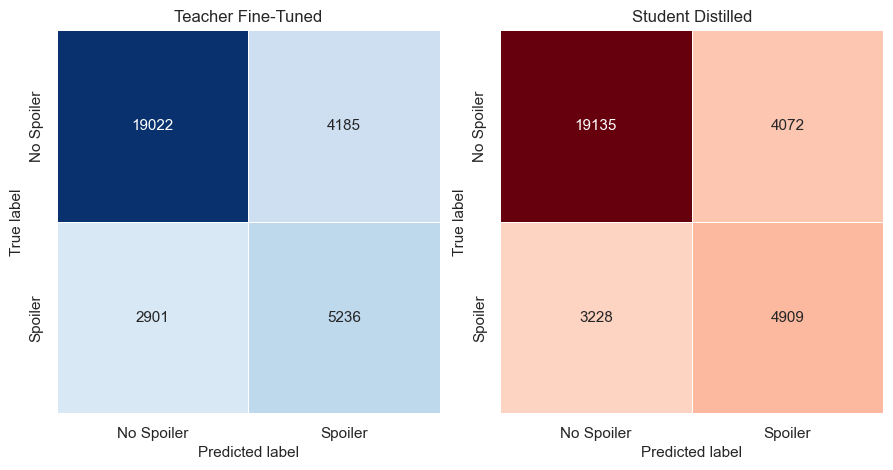

In [9]:
fig_cm_abs, axes_cm_abs = plot_confusion_matrices(
    results_dict=results,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_ft", "student_kd"),
    normalized=False,
    figsize=(9, 4.6),
    annot_fontsize=11,
)
plt.show()

fig_cm_abs.savefig(FIG_DIR / "confusion_matrices_absolute.png", dpi=600)

## Plot 2: Bar char with all evaluation metrics for both the models

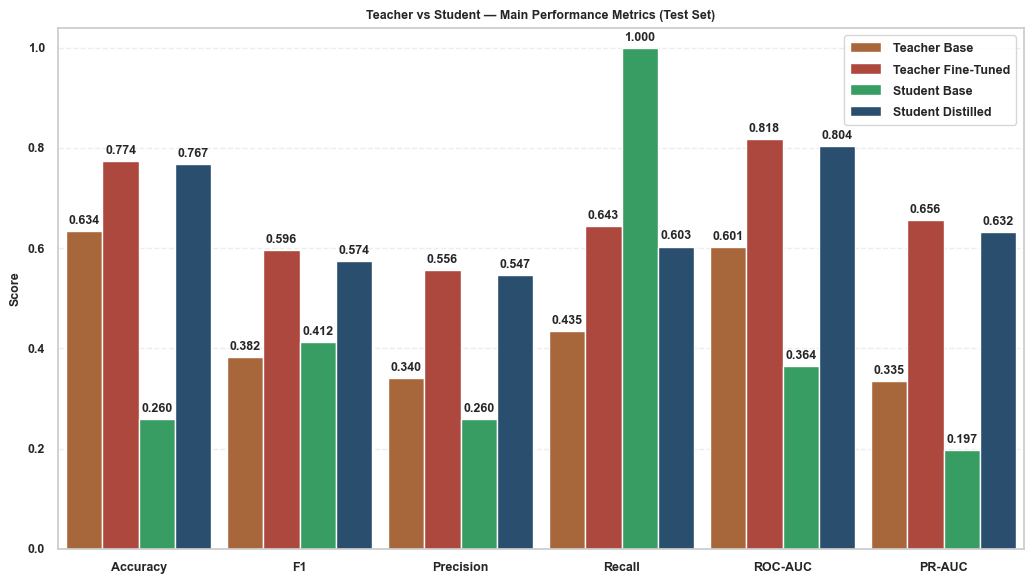

In [10]:
fig_bar_full, ax_bar_full = plot_metrics_barchart(
    df_metrics=df_metrics,
    specs_dict=MODEL_SPECS,
    model_keys=("teacher_base", "teacher_ft", "student_base", "student_kd"),
    figsize=(10.5, 6),
    y_lim=(0.0, 1.04),
    title="Teacher vs Student — Main Performance Metrics (Test Set)",
    show_values=True,
    fontsize = 9,
)
plt.show()

fig_bar_full.savefig(FIG_DIR / "metrics_barchart.png", dpi=1200)

## Plot 3: Scatter plots to evaluate inference time and memory usage of both models

In [39]:
def build_efficiency_dataframe(results_dict: Dict[str, Dict[str, Any]],model_keys) -> pd.DataFrame:
    rows = []
    for k in model_keys: 
        res = results_dict[k]
        rows.append({
            "ModelKey": k,
            "Model": res["display_name"],
            "PR-AUC": res["metrics"]["PR-AUC"],
            "ROC-AUC": res["metrics"]["ROC-AUC"],
            "F1": res["metrics"]["F1"],
            "ms_per_sample": res["timing"]["ms_per_sample"] if res["timing"] else np.nan,
            "samples_per_second": res["timing"]["samples_per_second"] if res["timing"] else np.nan,
            "n_params": res.get("n_params", np.nan),
            "color": MODEL_SPECS[k]["bar_color"],
        })
    return pd.DataFrame(rows) 

import matplotlib.lines as mlines

def plot_scatter_prauc_vs_time(df_eff: pd.DataFrame, title="PR-AUC vs Inference Time", fontsize=11):
    sns.set_theme(style="whitegrid", context="notebook")
    fig, ax = plt.subplots(figsize=(9, 6))

    legend_handles = []

    # 1. Disegniamo prima SOLO i punti (scatter) per far calcolare i limiti ottimali agli assi
    for _, r in df_eff.iterrows():
        x = r["ms_per_sample"]
        y = r["PR-AUC"]
        c = r["color"]
        label = r["Model"]

        ax.scatter([x], [y], s=140, color=c, edgecolor="white", linewidth=1.2, zorder=3)

        legend_handles.append(
            mlines.Line2D([], [], color=c, marker='o', linestyle='None',
                          markersize=9, label=label)
        )

    # 2. Blocchiamo i limiti degli assi in modo che le linee tratteggiate non li espandano ulteriormente
    ax.relim()
    ax.autoscale_view()
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # 3. Disegniamo le linee tratteggiate più fini (linewidth=0.8) fino ai margini appena bloccati
    line_width = 0.8
    for _, r in df_eff.iterrows():
        x = r["ms_per_sample"]
        y = r["PR-AUC"]
        c = r["color"]
        
        ax.vlines(x, ymin=y0, ymax=y, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)
        ax.hlines(y, xmin=x0, xmax=x, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)

    # 4. Formattazione: font universale e tutto in grassetto
    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel("Inference time (ms per sample) — Lower is better", fontsize=fontsize, fontweight='bold')
    ax.set_ylabel("PR-AUC — Higher is better", fontsize=fontsize, fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.35)

    # Grassetto e fontsize per i numeri sugli assi (ticks)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(fontsize)
        label.set_fontweight('bold')

    # 5. Legenda fuori dal plot in alto a destra, testi in grassetto
    legend = ax.legend(
        handles=legend_handles, 
        title="", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left", 
        frameon=True
    )
    for text in legend.get_texts():
        text.set_fontsize(fontsize)
        text.set_fontweight('bold')

    plt.tight_layout()
    return fig, ax
    


In [41]:

def plot_scatter_prauc_vs_params(df_eff: pd.DataFrame, title="PR-AUC vs Model Size (#parameters)", fontsize=11):
    sns.set_theme(style="whitegrid", context="notebook")
    fig, ax = plt.subplots(figsize=(9, 6))

    legend_handles = []

    # 1. Impostiamo prima la scala logaritmica per l'asse X
    ax.set_xscale("log")

    # 2. Disegniamo prima SOLO i punti (scatter) per far calcolare i limiti ottimali
    for _, r in df_eff.iterrows():
        x = r["n_params"]
        y = r["PR-AUC"]
        c = r["color"]
        label = r["Model"]

        ax.scatter([x], [y], s=140, color=c, edgecolor="white", linewidth=1.2, zorder=3)

        legend_handles.append(
            mlines.Line2D([], [], color=c, marker='o', linestyle='None',
                          markersize=9, label=label)
        )

    # 3. Blocchiamo i limiti degli assi (già in scala logaritmica)
    ax.relim()
    ax.autoscale_view()
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    # 4. Disegniamo le linee tratteggiate più fini (linewidth=0.8) fino ai margini
    line_width = 0.8
    for _, r in df_eff.iterrows():
        x = r["n_params"]
        y = r["PR-AUC"]
        c = r["color"]
        
        ax.vlines(x, ymin=y0, ymax=y, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)
        ax.hlines(y, xmin=x0, xmax=x, colors=c, linestyles="--", linewidth=line_width, alpha=0.9, zorder=2)

    # 5. Formattazione: font universale e tutto in grassetto
    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xlabel("# Parameters (log scale) — Lower is better", fontsize=fontsize, fontweight='bold')
    ax.set_ylabel("PR-AUC — Higher is better", fontsize=fontsize, fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.35)

    # Grassetto e fontsize per i numeri sugli assi (ticks)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(fontsize)
        label.set_fontweight('bold')

    # 6. Legenda fuori dal plot in alto a destra, testi in grassetto
    legend = ax.legend(
        handles=legend_handles, 
        title="", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left", 
        frameon=True
    )
    for text in legend.get_texts():
        text.set_fontsize(fontsize)
        text.set_fontweight('bold')

    plt.tight_layout()
    return fig, ax

In [ ]:
eff_keys = ["teacher_base", "teacher_ft", "student_base", "student_kd"]  

results_eff = {}
for k in eff_keys:
    print(f"Evaluating {k} with timing...")
    results_eff[k] = evaluate_model_on_test(MODEL_SPECS[k], test_ds, batch_size=32, measure_time=True)
    print("  ms/sample:", results_eff[k]["timing"]["ms_per_sample"])
    print("  PR-AUC:", results_eff[k]["metrics"]["PR-AUC"])



Evaluating teacher_base with timing...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 10.369328586013294
  PR-AUC: 0.22639613596186847
Evaluating teacher_ft with timing...


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 10.42054783371618
  PR-AUC: 0.6563758339791912
Evaluating student_base with timing...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 2.316628732771766
  PR-AUC: 0.19706602969678572
Evaluating student_kd with timing...


C:\Users\cola0\AppData\Local\Temp\ipykernel_19596\349597760.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


  ms/sample: 2.3126943115110685
  PR-AUC: 0.6317986032500638


,ModelKey,Model,PR-AUC,ROC-AUC,F1,ms_per_sample,samples_per_second,n_params,color
0,teacher_base,Teacher Base,0.226396,0.433881,0.411139,10.369329,96.438259,109482240,#333333
1,teacher_ft,Teacher Fine-Tuned,0.656376,0.818076,0.596423,10.420548,95.964244,109482240,#333333
2,student_base,Student Base,0.197066,0.364079,0.412198,2.316629,431.661744,14500000,#333333
3,student_kd,Student Distilled,0.631799,0.803560,0.573548,2.312694,432.396100,14500000,#333333


In [35]:
df_eff = build_efficiency_dataframe(results_eff, eff_keys)
df_eff

,ModelKey,Model,PR-AUC,ROC-AUC,F1,ms_per_sample,samples_per_second,n_params,color
0,teacher_base,Teacher Base,0.226396,0.433881,0.411139,10.369329,96.438259,109482240,#b96329
1,teacher_ft,Teacher Fine-Tuned,0.656376,0.818076,0.596423,10.420548,95.964244,109482240,#c0392b
2,student_base,Student Base,0.197066,0.364079,0.412198,2.316629,431.661744,14500000,#27ae60
3,student_kd,Student Distilled,0.631799,0.803560,0.573548,2.312694,432.396100,14500000,#1f4e79


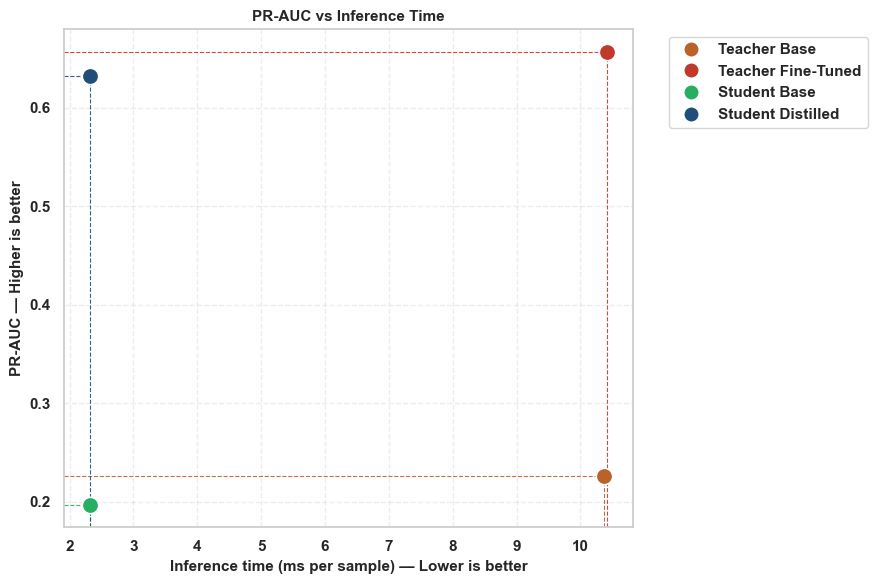

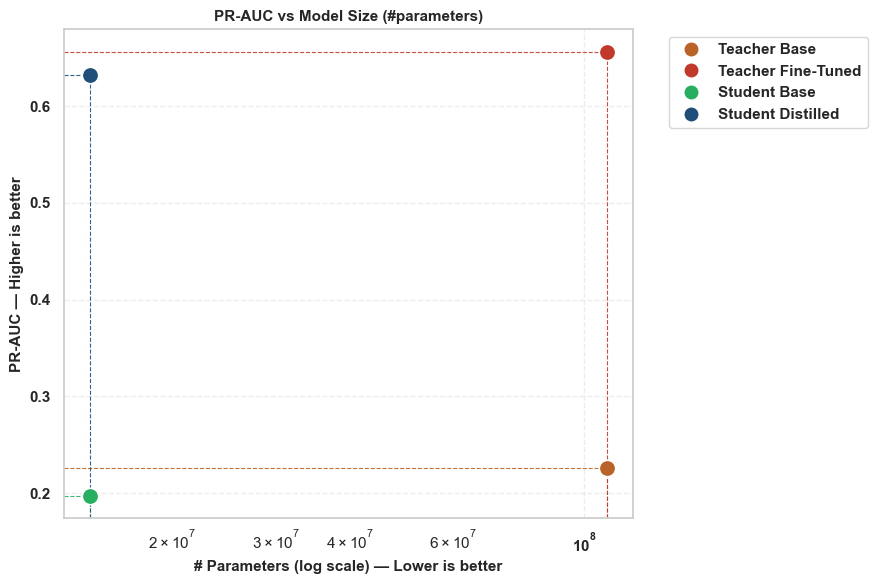

In [42]:
fig1, ax1 = plot_scatter_prauc_vs_time(df_eff, title="PR-AUC vs Inference Time")
plt.show()
fig1.savefig(FIG_DIR / "scatter_time_auc.png", dpi=600)


fig2, ax2 = plot_scatter_prauc_vs_params(df_eff, title="PR-AUC vs Model Size (#parameters)")
plt.show()
fig2.savefig(FIG_DIR / "scatter_params_auc.png", dpi=600)
